In [1]:
import uproot
import pandas as pd


important_variables = ['mcnhits', 'mcPEWavelength','mcpecount','mcparticlecount']

In [3]:
#10_000 photons and 100 events (One million photons) ground setup
with uproot.open("/home/silver/PTPSim/results/output.ntuple_1M_2sipm.root") as file:
    print(file.keys())
    tree =  file["output"]
    tree_meta = file["meta"]
    df = tree.arrays(library="pd")
    df_meta = tree_meta.arrays(library="pd")

['meta;1', 'output;1']


In [4]:
valeurs_unique_sipm_ID = []
for nbr in df_meta['pmtId'][0]:
    if nbr not in valeurs_unique_sipm_ID:
        valeurs_unique_sipm_ID.append(int(nbr))
print(valeurs_unique_sipm_ID)
print(len(valeurs_unique_sipm_ID))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59]
60


In [5]:
valeurs_unique_sipm_ID_too = []
for i in range(len(df["mcPEPMTID"])):
    for nbr in df["mcPEPMTID"][i]:    
        if nbr not in valeurs_unique_sipm_ID_too:
            valeurs_unique_sipm_ID_too.append(int(nbr))
valeurs_unique_sipm_ID_too.sort()
print(valeurs_unique_sipm_ID_too)
print(len(valeurs_unique_sipm_ID_too))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59]
60


In [6]:
from collections import Counter
liste_plat = [int(element) for sous_liste in df["mcPEPMTID"] for element in sous_liste]
liste_plat.sort()
dict_for_plot = dict(Counter(liste_plat))

In [7]:
print(dict_for_plot)

{0: 425, 1: 443, 2: 449, 3: 387, 4: 472, 5: 489, 6: 421, 7: 402, 8: 399, 9: 489, 10: 430, 11: 550, 12: 497, 13: 390, 14: 473, 15: 395, 16: 383, 17: 396, 18: 347, 19: 374, 20: 386, 21: 409, 22: 446, 23: 514, 24: 465, 25: 431, 26: 475, 27: 454, 28: 414, 29: 383, 30: 50, 31: 85, 32: 30, 33: 36, 34: 40, 35: 81, 36: 46, 37: 31, 38: 27, 39: 40, 40: 60, 41: 137, 42: 69, 43: 65, 44: 92, 45: 31, 46: 35, 47: 35, 48: 32, 49: 23, 50: 32, 51: 62, 52: 87, 53: 59, 54: 51, 55: 27, 56: 93, 57: 84, 58: 27, 59: 25}


In [8]:
df["mcPEPMTID"]

0     [16, 16, 16, 1, 1, 1, 1, 35, 22, 22, 22, 22, 2...
1     [13, 13, 13, 13, 13, 13, 13, 13, 13, 2, 2, 2, ...
2     [42, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 8, 8, 8,...
3     [23, 23, 23, 23, 23, 23, 2, 2, 21, 21, 21, 21,...
4     [12, 12, 12, 12, 12, 12, 23, 23, 23, 23, 23, 1...
                            ...                        
95    [16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 1...
96    [12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 1...
97    [3, 3, 3, 3, 29, 29, 29, 29, 16, 16, 16, 15, 1...
98    [6, 6, 6, 6, 6, 6, 17, 17, 17, 3, 3, 3, 3, 3, ...
99    [17, 17, 17, 17, 17, 17, 25, 25, 25, 25, 25, 2...
Name: mcPEPMTID, Length: 100, dtype: awkward

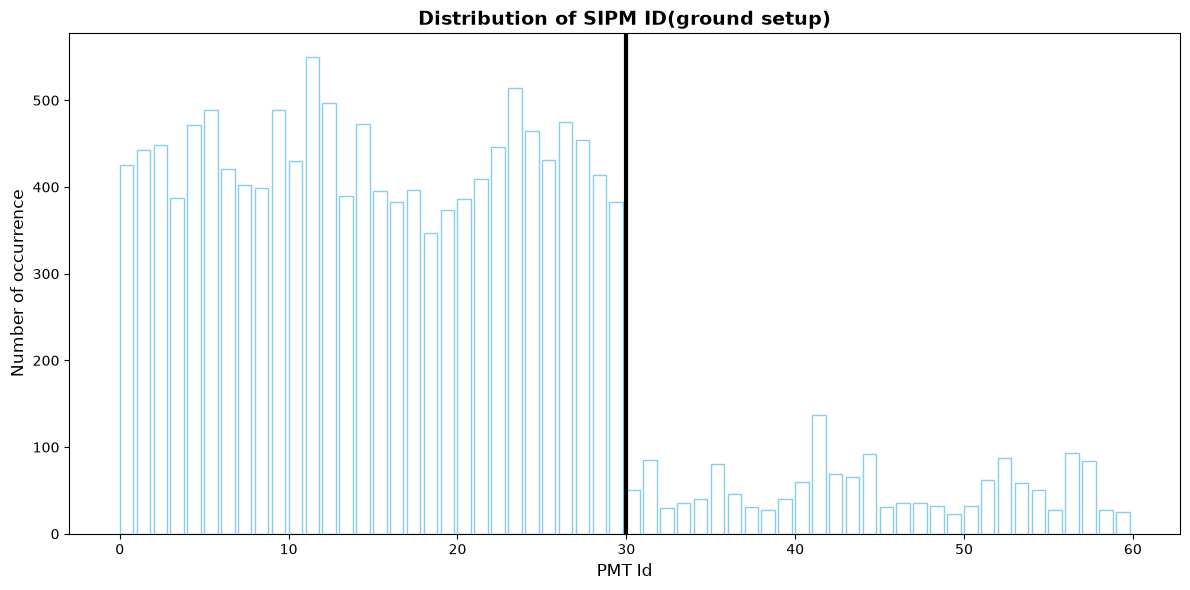

In [9]:
import matplotlib.pyplot as plt

# 1. Configurer la taille du graphique
plt.figure(figsize=(12, 6))

# 2. Dessiner le diagramme en barres
plt.bar(
    list(dict_for_plot.keys()),
    list(dict_for_plot.values()),
    color="white",
    edgecolor="skyblue",
    align="edge",
)
plt.axvline(x=30, color='black', linewidth=3, linestyle='-')
# 4. Personnaliser les titres et les axes
plt.title(
    "Distribution of SIPM ID(ground setup)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("PMT Id", fontsize=12)
plt.ylabel("Number of occurrence", fontsize=12)

# Évite que les étiquettes du bas ou des côtés soient coupées
plt.tight_layout()

# 6. Afficher le graphique
plt.show()


In [10]:
#efficiency
sum_mcnhist = 0
sum_nb_wvlght = 0
sum_mcpecount = 0
sum_all_PE_treated = 0
for j in range(len(df[important_variables[0]])):
    sum_mcnhist = sum_mcnhist + df[important_variables[0]][j]
    sum_nb_wvlght = sum_nb_wvlght +len(df[important_variables[1]][j])
    sum_mcpecount = sum_mcpecount + df[important_variables[2]][j]
    sum_all_PE_treated = sum_all_PE_treated + df['mcparticlecount'][j]
print(f'There was {sum_mcnhist} total values in mcnhits and there was {sum_nb_wvlght} values in the wavelentgh, and has {sum_mcpecount} mcpacount  over {sum_all_PE_treated} in total')
print(f'So the efficiency may be {(sum_mcpecount*100)/sum_all_PE_treated}%')

There was 3080 total values in mcnhits and there was 14580 values in the wavelentgh, and has 14580 mcpacount  over 1000000 in total
So the efficiency may be 1.458%


In [29]:
df_meta.columns

Index(['runId', 'runType', 'runTime', 'dsentries', 'macro', 'pmtType', 'pmtId',
       'pmtChannel', 'pmtIsOnline', 'pmtCableOffset', 'pmtChargeScale',
       'pmtPulseWidthScale', 'pmtX', 'pmtY', 'pmtZ', 'pmtU', 'pmtV', 'pmtW',
       'digitizerWindowSize', 'digitizerSampleRate_GHz',
       'digitizerDynamicRange_mV', 'digitizerResolution_mVPerADC', 'calibId',
       'calibMode', 'calibIntensity', 'calibWavelength', 'calibName',
       'calibTime', 'calibX', 'calibY', 'calibZ', 'calibU', 'calibV',
       'calibW'],
      dtype='str')

In [36]:
print(list(df_meta['runId']))

[1]


In [37]:
print(list(df_meta['pmtId']))

[<Array [0, 1, 2, 3, 4, 5, 6, ..., 53, 54, 55, 56, 57, 58, 59] type='60 * int32'>]


In [38]:
df['mcPEPMTID']

0     [16, 16, 16, 1, 1, 1, 1, 35, 22, 22, 22, 22, 2...
1     [13, 13, 13, 13, 13, 13, 13, 13, 13, 2, 2, 2, ...
2     [42, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 8, 8, 8,...
3     [23, 23, 23, 23, 23, 23, 2, 2, 21, 21, 21, 21,...
4     [12, 12, 12, 12, 12, 12, 23, 23, 23, 23, 23, 1...
                            ...                        
95    [16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 1...
96    [12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 1...
97    [3, 3, 3, 3, 29, 29, 29, 29, 16, 16, 16, 15, 1...
98    [6, 6, 6, 6, 6, 6, 17, 17, 17, 3, 3, 3, 3, 3, ...
99    [17, 17, 17, 17, 17, 17, 25, 25, 25, 25, 25, 2...
Name: mcPEPMTID, Length: 100, dtype: awkward

In [12]:
total_PE = df['mcparticlecount'][0]
print(total_PE)

10000


In [13]:
#plots
all_wavelenght = []
for pack_wfm in range(len(df[important_variables[1]])):
    for one_wfm in range(len(df[important_variables[1]][pack_wfm])):
        all_wavelenght.append(df[important_variables[1]][pack_wfm][one_wfm])
print(len(all_wavelenght))

14580


In [14]:
data_wvlght = pd.DataFrame(all_wavelenght, columns = ['Wavelenght'])

In [15]:
data_wvlght.describe()

,Wavelenght
count,14580.000000
mean,0.000434
std,0.000031
min,0.000302
25%,0.000419
50%,0.000433
75%,0.000451
max,0.000530


In [16]:
data_wvlght['Wavelenght'].unique()

array([0.00042728, 0.00046292, 0.00044094, ..., 0.00051173, 0.00041955,
       0.00041915], shape=(14477,))

In [17]:
data_wvlght['Wavelenght'].nunique()

14477

In [18]:
data_wvlght["Intervalle_Num"] = (
    data_wvlght['Wavelenght'] // 0.000005
) * 5

In [19]:
data_wvlght.head()

,Wavelenght,Intervalle_Num
0,0.000427,425.0
1,0.000463,460.0
2,0.000441,440.0
3,0.000463,460.0
4,0.000422,420.0


In [20]:
for_plot = pd.DataFrame(
    {"Wavelenght": sorted(data_wvlght["Intervalle_Num"].unique())}
)

In [21]:
for_plot = pd.DataFrame(
    {"Wavelenght": sorted(data_wvlght["Intervalle_Num"].unique())}
)

In [22]:
len(for_plot['Wavelenght'])

46

In [23]:
for_plot = (
    data_wvlght["Intervalle_Num"]
    .value_counts()
    .reset_index(name="Compte")
)

In [24]:
for_plot.head()

,Intervalle_Num,Compte
0,420.0,1376
1,415.0,1371
2,425.0,1348
3,430.0,1309
4,435.0,1161


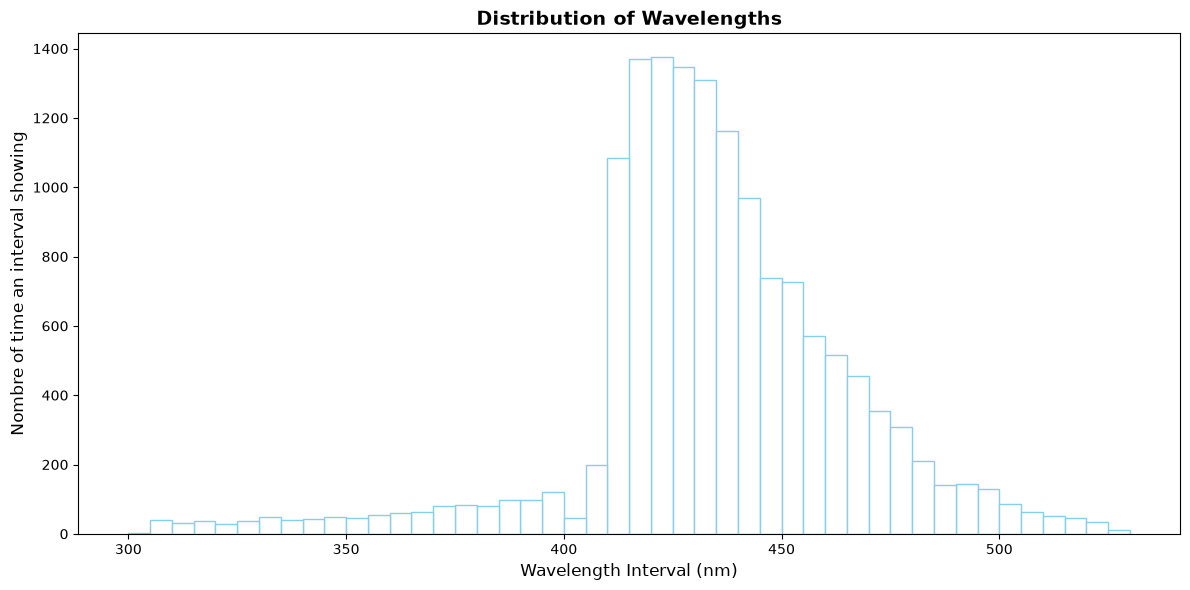

In [25]:
import matplotlib.pyplot as plt

# 1. Configurer la taille du graphique
plt.figure(figsize=(12, 6))

# 2. Dessiner le diagramme en barres
# width=0.0000045 permet de laisser un tout petit espace noir entre les barres pour le style
plt.bar(
    for_plot["Intervalle_Num"],
    for_plot["Compte"],
    width=5,
    color="white",
    edgecolor="skyblue",
    align="edge",
)

# 4. Personnaliser les titres et les axes
plt.title(
    "Distribution of Wavelengths",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Wavelength Interval (nm)", fontsize=12)
plt.ylabel("Nombre of time an interval showing", fontsize=12)

# Évite que les étiquettes du bas ou des côtés soient coupées
plt.tight_layout()

# 6. Afficher le graphique
plt.show()


In [26]:
print(for_plot.columns)


Index(['Intervalle_Num', 'Compte'], dtype='str')
